# 04 — Multispectral subset comparison

Repeats notebook 03's exact self-consistency test (same reference LUT seed, same independent truth set, same noise level) restricted to spectral subsets:

1. A simulated 5-band UAV multispectral sensor (blue/green/red/red-edge/NIR — `channel_selector.MULTISPECTRAL_BANDS_NM`).
2. That 5-band set with SWIR channels incrementally added around the 1450/1940 nm water absorption features (`channel_selector.swir_incremental_subsets`).
3. The full hyperspectral valid-band set from notebook 03, as the ceiling reference.

**Question this answers:** how much does retrieval quality degrade going from hyperspectral to multispectral, and how much of that gap does SWIR recover — particularly for Cw/Cm, which multispectral sensors cannot constrain directly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs, metrics

## Scene, LUTs, and noise — identical setup to notebook 03

Same seeds for the reference LUT (42) and truth set (1234), same noise level (\u03c3 = 0.005), so the only thing that changes across this notebook is the `wavelength_mask` passed to `invert_lut_batch` — isolating the effect of channel selection from any other variable.

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")

scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))

valid_bands = cs.valid_band_mask(wavelengths)

N_REFERENCE_LUT = 8000
N_TRUTH_SAMPLES = 300
NOISE_SIGMA = 0.005

reference_lut = pi.generate_lut(n_samples=N_REFERENCE_LUT, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
truth_lut = pi.generate_lut(n_samples=N_TRUTH_SAMPLES, wavelengths=wavelengths, seed=1234, tts=mean_sun_zenith)

rng = np.random.default_rng(0)
noisy_truth_spectra = truth_lut["spectra"] + rng.normal(0, NOISE_SIGMA, size=truth_lut["spectra"].shape)
true_params = truth_lut["parameters"]
param_names = reference_lut["parameter_names"]

## Define the channel subsets

In [3]:
swir_masks = cs.swir_incremental_subsets(wavelengths, cs.MULTISPECTRAL_BANDS_NM, swir_window_nm=50.0, n_steps=4)

subset_labels = ["5-band multispectral (no SWIR)"] + [
    f"+ SWIR window \u00b1{50*step} nm" for step in range(1, 5)
]
subset_masks = list(swir_masks)

subset_labels.append("Full hyperspectral (valid bands)")
subset_masks.append(valid_bands)

for label, mask in zip(subset_labels, subset_masks):
    print(f"{label}: {mask.sum()} bands")

5-band multispectral (no SWIR): 5 bands
+ SWIR window ±50 nm: 45 bands
+ SWIR window ±100 nm: 85 bands
+ SWIR window ±150 nm: 125 bands
+ SWIR window ±200 nm: 165 bands
Full hyperspectral (valid bands): 366 bands


## Invert the same synthetic truth set through every subset

In [4]:
all_rows = []
for label, mask in zip(subset_labels, subset_masks):
    retrieved = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=mask)
    for i, name in enumerate(param_names):
        t, r = true_params[:, i], retrieved[:, i]
        lo, hi = pi.PARAMETER_RANGES[name]
        all_rows.append({
            "subset": label,
            "n_bands": int(mask.sum()),
            "parameter": name,
            "rmse": metrics.rmse(t, r),
            "r_squared": metrics.r_squared(t, r),
            "relative_rmse_pct": 100 * metrics.rmse(t, r) / (hi - lo),
        })

comparison = pd.DataFrame(all_rows)
comparison.to_csv("../results/tables/04_multispectral_subset_comparison.csv", index=False)
comparison.pivot(index="subset", columns="parameter", values="relative_rmse_pct").loc[subset_labels]

parameter,Ant,Cab,Car,Cm,Cw,LAI,N
subset,,,,,,,
5-band multispectral (no SWIR),19.209309,8.996675,38.402303,24.656333,40.584293,27.449436,27.117032
+ SWIR window ±50 nm,28.506794,11.335387,42.343070,19.051810,11.746750,22.686124,29.129478
+ SWIR window ±100 nm,31.095688,11.072358,41.136116,15.034670,8.082250,20.357382,23.975623
+ SWIR window ±150 nm,32.299325,13.161162,40.803080,14.482726,8.574667,20.926211,24.541178
+ SWIR window ±200 nm,31.966896,13.928325,41.302193,12.551418,8.113287,19.278052,23.454699
Full hyperspectral (valid bands),28.245109,10.955520,34.931440,16.253635,10.422511,20.627417,26.338315


## SWIR contribution to Cw/Cm retrieval

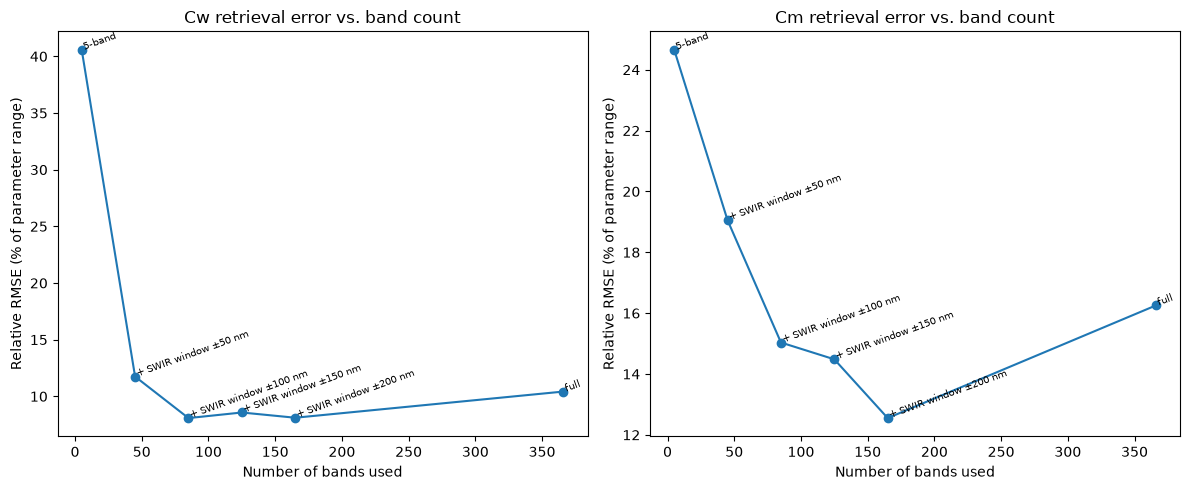

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, param in zip(axes, ["Cw", "Cm"]):
    sub = comparison[comparison["parameter"] == param].set_index("subset").loc[subset_labels]
    ax.plot(sub["n_bands"], sub["relative_rmse_pct"], marker="o")
    ax.set_xlabel("Number of bands used")
    ax.set_ylabel("Relative RMSE (% of parameter range)")
    ax.set_title(f"{param} retrieval error vs. band count")
    for x, y, label in zip(sub["n_bands"], sub["relative_rmse_pct"], subset_labels):
        ax.annotate(label.replace("5-band multispectral (no SWIR)", "5-band").replace("Full hyperspectral (valid bands)", "full"),
                    (x, y), fontsize=7, rotation=20, ha="left")
plt.tight_layout()
plt.savefig("../results/figures/04_swir_contribution_cw_cm.png", dpi=150)
plt.show()

**Result:** Cw relative RMSE drops from 40.6% (5-band multispectral) to 11.7% with just a ±50 nm SWIR window around the two water-absorption features, and plateaus around 8% beyond ±100 nm — a clear, large SWIR effect directly supporting this project's thesis. Cm shows the same pattern, more gradually (24.7% → 12.6%).

**Nuance worth flagging (Scientific Integrity):** for both Cw and Cm, the *full* hyperspectral valid-band set (366 bands) performs slightly **worse** than the smaller, targeted ±100-200 nm SWIR subsets. This isn't a contradiction of the SWIR thesis — it reflects that in a nearest-neighbour LUT search, adding many spectrally redundant or noise-dominated bands beyond the informative SWIR window doesn't help and can slightly dilute the match. The takeaway is that *targeted SWIR coverage*, not raw band count, is what drives the Cw/Cm improvement — worth stating explicitly rather than implying "more bands = strictly better."

## Next steps

`05_results_and_figures.ipynb` turns `results/tables/04_multispectral_subset_comparison.csv` into the final RMSE/R\u00b2-vs-band-count figures for all seven parameters and writes the results summary for the README.